# Regresión Lineal
Una regresión lineal es un modelo estadístico que establece una relación **lineal** entre una variable dependiente (Y) y una o más variables independientes (X_1, X_2, …, X_k), usándose la ecuación de una recta en el caso simple, o un hiperplano en múltiples dimensiones en la forma general:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon $$
En su forma matricial tiene la siguiente forma:


$$Y = X\beta + \varepsilon$$

**Donde:**
- **Y** es el vector de observaciones, $ \mathbf{y} = (y_1, y_2, \dots, y_n)^T$ (variable dependiente).
- **X** es la matriz de diseño de $n \times (p+1)$ con una columna de unos (para el intercepto).
- **β** es el vector de coeficientes a estimar.
- **ε** es el vector de errores.
Nota: $\epsilon \sim N(0,\sigma_0^2)$

## Simulación

In [113]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

$$ f(x) = m x + b $$

In [224]:
n  = 1000
x = np.linspace(-10, 10, n)
m = 2.5
b = 0.0

y_fijo = m * x + b


### Añadimos un poco de ruido


In [225]:
y_fijo.shape[0]

1000

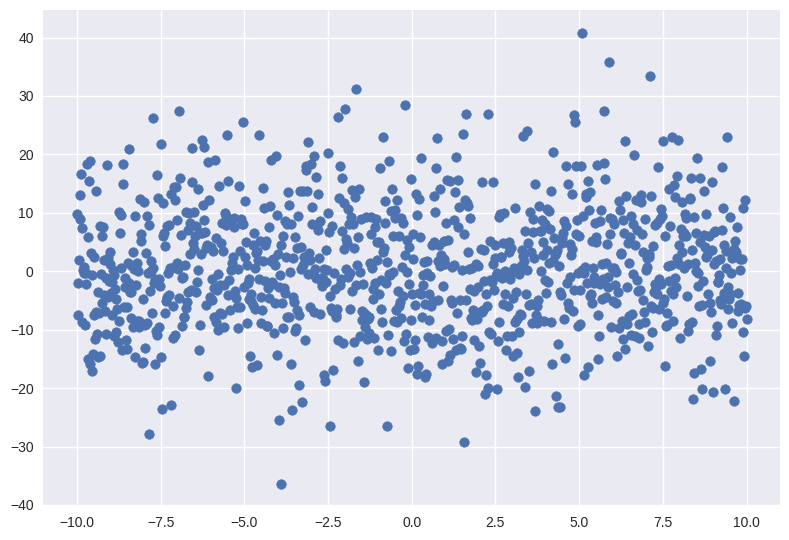

In [226]:
sigma = 10
eps = np.random.normal(0.0,sigma,size=y_fijo.shape[0])
plt.scatter(x,eps)

- Cuando $\sigma$ es constante, se dice que el modelo es *Homocedastícico*
- Caso contrario se dice que el modelo es *Heterocedastícico*

(array([  2.,  15.,  67., 202., 301., 247., 106.,  45.,  12.,   3.]),
 array([-36.36435829, -28.64253228, -20.92070628, -13.19888027,
         -5.47705426,   2.24477175,   9.96659776,  17.68842377,
         25.41024978,  33.13207578,  40.85390179]),
 <BarContainer object of 10 artists>)

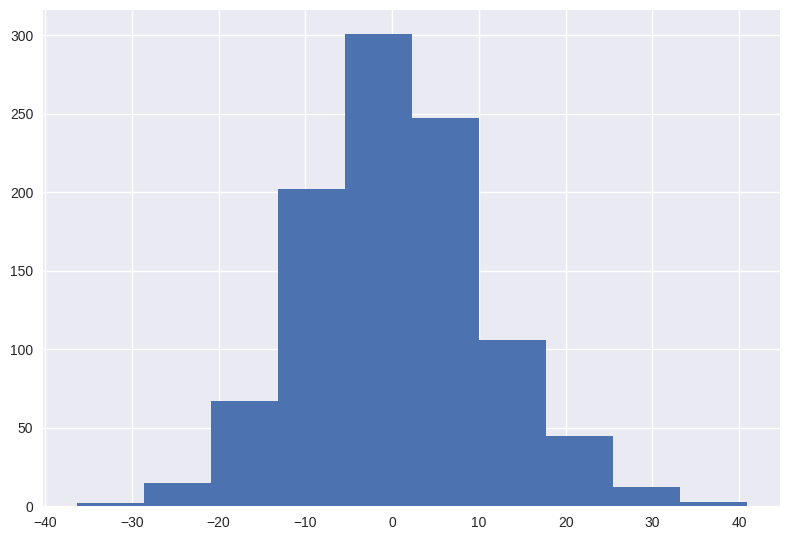

In [227]:
plt.hist(eps)

In [260]:
# Señal, efecto fijo con ruido 
y = y_fijo + eps

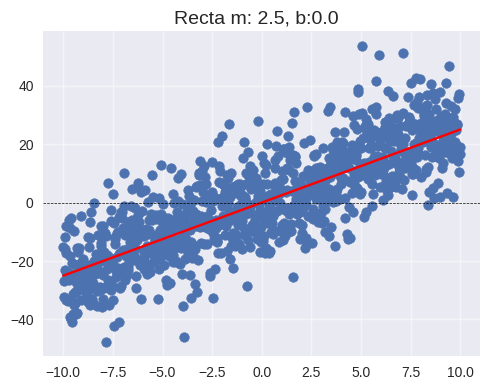

In [261]:
fig, axes = plt.subplots(1, 1, figsize=(5, 4))

# Positivo positivo
ax = axes
ax.scatter(x, y)
ax.plot(x,y_fijo,color='red')
ax.set_title(f"Recta m: {m}, b:{b}  ", fontsize=14)
ax.grid(alpha=0.5)
ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--", zorder=4)
plt.rcParams.update({"figure.autolayout": True})

plt.show()

In [262]:
beta = np.array([45,22,65,33])
X = np.random.uniform(-10,10,size=(n,beta.shape[0]))

A X se le llama **Matríz de Diseño**, **Matríz de covariables**

In [263]:
Y = np.dot(X,beta) + np.transpose(eps)

En este caso, $Y$ es un vector de dimensión, $n$. Y le vamos a llamar, la variable de respuesta, las observaciones, salida, etc.

In [264]:
import pandas as pd

In [265]:
X_df = pd.DataFrame(X,columns=["Col1","Col2", "Col3", "Col4"])

In [266]:
Y_df = pd.DataFrame(Y,columns=["Y"])


# Ajuste de modelo lineal con Scikit-learn

In [269]:
import sklearn as sk

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

Generamos una partición de las observaciones en dos grupos: Entrenamiento (train) y Prueba (test)

In [270]:
X_train, X_test, y_train, y_test = train_test_split(X_df,Y_df,test_size=0.2)

In [271]:
modelo = LinearRegression()

In [274]:
modelo

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Ajuste con datos de entrenamiento (Train)

In [275]:
modelo.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Extraemos coeficientes (atributos de la clase LinearRegression)

In [282]:
modelo.coef_

array([[44.96665819, 21.95180536, 64.94466554, 32.97718728]])

### Recordemos el valor original de los coeficientes utilizados ($\beta$)

In [283]:
beta

array([45, 22, 65, 33])

In [284]:
modelo.coef_ - beta

array([[-0.03334181, -0.04819464, -0.05533446, -0.02281272]])

## Métrica para medir desempeño del modelo

In [285]:
y_pred = modelo.predict(X_test)

In [286]:
mean_squared_error(y_test,y_pred)

125.60366080129667

Nota: Este error no tiene sentido si no se compara con otros modelos